# Predict NFL passing yards from public data with Nori

Run this notebook from a fresh Jupyter/Colab environment. It downloads football data and the public model, builds Q1/halftime features, generates fresh predictions, and measures forecast error. No saved predictions, internal files, or private checkpoint are required.

This portable model is a new baseline with a smaller feature set and explicit context cap. It does **not** claim to reproduce the blog’s selected 24.1% strategy. The default runs one test week; change MAX_WEEK to 18 for the complete season. Kalshi replay is optional and disabled by default.

In [1]:
import sys, subprocess, importlib.metadata as metadata
try:
    metadata.version('pip')
except metadata.PackageNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'ensurepip'])
required = {'synthefy-nori':'0.19.0', 'nflreadpy':'0.1.5'}
for package, version in required.items():
    try:
        installed = metadata.version(package)
    except metadata.PackageNotFoundError:
        installed = None
    if installed != version:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package+'=='+version])
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pandas', 'pyarrow', 'requests', 'matplotlib'])
print({p:metadata.version(p) for p in required})

Looking in links: /tmp/tmpvmxwkga1
Processing /tmp/tmpvmxwkga1/pip-24.0-py3-none-any.whl


{'synthefy-nori': '0.19.0', 'nflreadpy': '0.1.5'}



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: /home/raimi/.codex/worktrees/6c3d/nori-monorepo/experiments/2026-08-25-nfl-qb-passing-yards/.venv/bin/python -m pip install --upgrade pip


## Download and feature-building implementation
The implementation is included below so a downloaded notebook works without fetching helper scripts. nflreadpy retrieves nflverse play-by-play and official weekly player statistics. Each source is cached with a content hash.

Rows use the first observed QB passer for each team by the checkpoint. Features include current passing usage and score, prior QB checkpoint production over three/eight games, and prior offense/defense summaries. QB, team and opponent are encoded using only model-context rows. Current-week outcomes are excluded from historical features. Injury/replacement outcomes remain in evaluation. Historical corrected play timestamps do not establish when a live data feed published each statistic.

In [2]:
"""Public-source Q1/halftime NFL passing-yard modeling baseline.

Downloads nflverse via nflreadpy; no saved predictions or private artifacts.
Retrospectively corrected play data and play timestamps are NOT a real-time
publication feed. This new baseline does not reproduce the blog's selected model.
"""
from __future__ import annotations

import argparse
import hashlib
import json
from pathlib import Path

import nflreadpy as nfl
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from synthefy_nori import NoriRegressor


CATEGORIES = ["actual_qb_id", "team", "opponent_team"]
LIVE = ["yards_so_far", "attempts_so_far", "dropbacks_so_far", "sacks_so_far",
        "epa_per_dropback", "cpoe", "air_yards_per_attempt", "sack_rate", "ypa",
        "offense_plays", "offense_pass_rate", "offense_epa", "score_margin"]


In [3]:
def _load(cache_dir, kind, season):
    path = Path(cache_dir) / f"{kind}_{season}.parquet"
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.exists():
        print(f"Downloading nflverse {kind} {season}", flush=True)
        loader = nfl.load_pbp if kind == "pbp" else nfl.load_player_stats
        loader([season]).write_parquet(path)
    manifest_path = Path(cache_dir) / f"{kind}_{season}.source.json"
    manifest_path.write_text(json.dumps({"loader": f"nflreadpy.load_{kind}", "season": season,
        "sha256": hashlib.sha256(path.read_bytes()).hexdigest(), "bytes": path.stat().st_size}, indent=2))
    return pd.read_parquet(path)


In [4]:
def _sum(frame, col):
    return float(frame[col].fillna(0).sum())


In [5]:
def _mean(frame, col):
    return float(frame[col].mean()) if len(frame) else np.nan


In [6]:
def build_dataset(cache_dir, seasons, decision_delay_seconds=120):
    """One first-passer/team/game/checkpoint row, with earlier-week history.

    QB selection uses the first identified passer by the checkpoint, never final
    attempts. Injury/replacement outcomes remain in evaluation. Missing official
    labels are excluded, not fabricated. No final-game weather or betting lines
    are features because their historical publication times are unknown.
    """
    if decision_delay_seconds < 0:
        raise ValueError("decision_delay_seconds must be nonnegative")
    records = []
    for season in sorted(set(seasons)):
        pbp = _load(cache_dir, "pbp", season)
        stats = _load(cache_dir, "player_stats", season)
        stats = stats.loc[stats.season_type == "REG"]
        qb_ids = set(stats.loc[stats.position == "QB", "player_id"])
        stats = stats.set_index(["game_id", "player_id"])
        pbp = pbp.loc[pbp.season_type == "REG"].copy()
        pbp["_utc"] = pd.to_datetime(pbp.time_of_day, utc=True, errors="coerce")
        for game_id, game in pbp.groupby("game_id", sort=True):
            game = game.sort_values("play_id")
            for quarter, checkpoint in [(1, "q1"), (2, "halftime")]:
                quarter_rows = game.loc[game.qtr == quarter]
                anchor = quarter_rows._utc.max()
                if pd.isna(anchor):
                    continue
                seen = game.loc[game.qtr.between(1, quarter) & (game._utc <= anchor)]
                if seen.empty:
                    continue
                last = seen.iloc[-1]
                for team in [last.home_team, last.away_team]:
                    offense = seen.loc[seen.posteam == team]
                    passers = offense.loc[offense.passer_player_id.isin(qb_ids)]
                    if passers.empty:
                        continue
                    qb_id = passers.iloc[0].passer_player_id
                    if (game_id, qb_id) not in stats.index:
                        continue
                    label = stats.loc[(game_id, qb_id)]
                    if isinstance(label, pd.DataFrame):
                        raise ValueError(f"Duplicate official label: {game_id}/{qb_id}")
                    qb = offense.loc[(offense.passer_player_id == qb_id) |
                                     ((offense.rusher_player_id == qb_id) & (offense.qb_dropback == 1))]
                    drops = qb.loc[qb.qb_dropback == 1]
                    attempts = qb.loc[(qb.pass_attempt == 1) & (qb.sack != 1) & (qb.two_point_attempt != 1)]
                    valid = offense.loc[offense.play_type.isin(["pass", "run"])]
                    yards = _sum(qb.loc[qb.two_point_attempt != 1], "passing_yards")
                    home = team == last.home_team
                    rec = dict(game_id=game_id, game_date=str(last.game_date), season=int(season),
                               week=int(last.week), team=team,
                               opponent_team=last.away_team if home else last.home_team,
                               actual_qb_id=qb_id, actual_qb_name=label.player_display_name,
                               checkpoint=checkpoint, live_anchor_utc=anchor,
                               game_end_utc=game._utc.max() + pd.Timedelta(minutes=5),
                               decision_utc=anchor + pd.Timedelta(seconds=decision_delay_seconds),
                               official_passing_yards=float(label.passing_yards),
                               home=int(home), seconds_remaining=3600-quarter*900,
                               yards_so_far=yards, attempts_so_far=float(len(attempts)),
                               dropbacks_so_far=float(len(drops)), sacks_so_far=_sum(qb, "sack"),
                               epa_per_dropback=_mean(drops, "epa"), cpoe=_mean(attempts, "cpoe"),
                               air_yards_per_attempt=_mean(attempts, "air_yards"),
                               sack_rate=_sum(qb, "sack") / max(len(drops), 1),
                               ypa=yards / max(len(attempts), 1), offense_plays=float(len(valid)),
                               offense_pass_rate=_mean(valid, "qb_dropback"), offense_epa=_mean(valid, "epa"),
                               score_margin=float(last.total_home_score-last.total_away_score)*(1 if home else -1))
                    rec["remaining_yards"] = rec["official_passing_yards"] - yards
                    records.append(rec)
    rows = pd.DataFrame(records).sort_values(["season", "week", "game_id", "checkpoint"]).reset_index(drop=True)
    if rows.empty:
        raise ValueError("No timestamped checkpoint rows with official labels")
    return add_history(rows)


In [7]:
def add_history(rows):
    """Group matching-checkpoint histories; embargo the entire current week."""
    rows = rows.copy()
    for checkpoint, idx in rows.groupby("checkpoint").groups.items():
        part = rows.loc[idx]
        for index, row in part.iterrows():
            prior = part.loc[((part.season < row.season) | ((part.season == row.season) & (part.week < row.week)))
                             & (part.game_end_utc < row.live_anchor_utc)]
            qb = prior.loc[prior.actual_qb_id == row.actual_qb_id]
            for window in [3, 8]:
                hist = qb.tail(window)
                for col in LIVE + ["remaining_yards", "official_passing_yards"]:
                    rows.loc[index, f"qb_prior{window}_{col}"] = hist[col].mean()
            rows.loc[index, "qb_prior_games"] = len(qb)
            if not qb.empty:
                rows.loc[index, "rest_days"] = (pd.Timestamp(row.game_date) - pd.Timestamp(qb.iloc[-1].game_date)).days
            for name, key, value in [("offense", "team", row.team), ("defense", "opponent_team", row.opponent_team)]:
                hist = prior.loc[prior[key] == value].tail(8)
                for col in ["ypa", "epa_per_dropback", "sack_rate", "offense_pass_rate", "offense_plays"]:
                    rows.loc[index, f"{name}_prior8_{col}"] = hist[col].mean()
    return rows


In [8]:
def feature_columns(rows):
    return ["week", "home", "seconds_remaining"] + LIVE + [c for c in rows if "_prior" in c or c == "rest_days"]


In [9]:
def predict_weekly(rows, test_season, max_week=18, device="cpu", context_limit=512,
                   min_week=1, model="nori-6m", weekly_update=True):
    """Fresh public Nori predictions, independently per checkpoint and week."""
    if context_limit < 2:
        raise ValueError("context_limit must be >= 2")
    outputs = []
    features = feature_columns(rows)
    model_instance = NoriRegressor(model=model, device=device)
    for week in range(min_week, max_week + 1):
        for checkpoint in ["q1", "halftime"]:
            available = rows.loc[rows.checkpoint == checkpoint]
            train = available.loc[(available.season < test_season) |
                                  (weekly_update & (available.season == test_season) & (available.week < week))]
            train = train.sort_values(["season", "week", "game_id"]).tail(context_limit)
            test = available.loc[(available.season == test_season) & (available.week == week)].copy()
            if test.empty:
                continue
            train = train.loc[train.game_end_utc < test.live_anchor_utc.min()]
            if len(train) < 2:
                raise ValueError(f"Insufficient prior context for {test_season} week {week}")
            encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
            xc = encoder.fit_transform(train[CATEGORIES].fillna("unknown"))
            xq = encoder.transform(test[CATEGORIES].fillna("unknown"))
            xtrain = np.column_stack([train[features].to_numpy(dtype=float), xc])
            xtest = np.column_stack([test[features].to_numpy(dtype=float), xq])
            print(f"Nori {test_season} W{week} {checkpoint}: {len(train)} context, {len(test)} queries", flush=True)
            model_instance.fit(xtrain, train.remaining_yards.to_numpy())
            dist = model_instance.predict(xtest, output_type="full")
            quantiles = np.asarray(dist["quantiles"]) + test.yards_so_far.to_numpy()[:, None]
            taus = np.asarray(dist["taus"])
            test["predicted_mean"] = np.asarray(dist["mean"]).reshape(-1) + test.yards_so_far.to_numpy()
            test["quantile_levels"] = [taus.tolist() for _ in range(len(test))]
            test["quantile_values"] = quantiles.tolist()
            test["context_rows"] = len(train)
            test["model"] = model
            for tau, label in [(0.1, "p10"), (0.5, "p50"), (0.9, "p90")]:
                test[label] = [np.interp(tau, taus, q) for q in quantiles]
            outputs.append(test)
    if not outputs:
        raise ValueError("No query rows in requested season/week range")
    return pd.concat(outputs, ignore_index=True)


In [10]:
def prediction_metrics(predictions):
    results = []
    for checkpoint, part in predictions.groupby("checkpoint"):
        actual = part.official_passing_yards.to_numpy()
        error = part.predicted_mean.to_numpy() - actual
        q = np.stack(part.quantile_values)
        taus = np.asarray(part.iloc[0].quantile_levels)
        residual = actual[:, None] - q
        results.append(dict(checkpoint=checkpoint, rows=len(part), mae=float(np.abs(error).mean()),
                            rmse=float(np.sqrt((error**2).mean())),
                            pinball_loss=float(np.maximum(taus*residual, (taus-1)*residual).mean()),
                            p10_p90_coverage=float(((actual >= part.p10) & (actual <= part.p90)).mean())))
    return pd.DataFrame(results)


In [11]:
def main():
    parser = argparse.ArgumentParser(description=__doc__)
    parser.add_argument("--cache-dir", default="data/nfl_passing_yards")
    parser.add_argument("--start-season", type=int, default=2023)
    parser.add_argument("--test-season", type=int, default=2025)
    parser.add_argument("--max-week", type=int, default=1)
    parser.add_argument("--context-limit", type=int, default=128)
    parser.add_argument("--device", default="cpu")
    parser.add_argument("--model", default="nori-6m")
    parser.add_argument("--features-only", action="store_true")
    args = parser.parse_args()
    rows = build_dataset(args.cache_dir, range(args.start_season, args.test_season+1))
    rows.to_parquet(Path(args.cache_dir)/"checkpoint_features.parquet", index=False)
    print(f"Built {len(rows)} checkpoint rows, {len(feature_columns(rows))+len(CATEGORIES)} features")
    if not args.features_only:
        pred = predict_weekly(rows, args.test_season, args.max_week, args.device, args.context_limit, model=args.model)
        pred.to_parquet(Path(args.cache_dir)/"predictions.parquet", index=False)
        metrics = prediction_metrics(pred)
        print(metrics.to_string(index=False))
        (Path(args.cache_dir)/"metrics.json").write_text(json.dumps(metrics.to_dict("records"), indent=2))



In [12]:
from pathlib import Path
import torch
CACHE_DIR = Path('nfl_passing_yards_cache')
OUTPUT_DIR = Path('nfl_passing_yards_outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
START_SEASON = 2024
TEST_SEASON = 2025
MIN_WEEK, MAX_WEEK = 1, 1  # Set MAX_WEEK=18 for the full regular season.
CONTEXT_LIMIT = 128  # Fixed before evaluation; larger contexts cost more compute.
DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
WEEKLY_UPDATE = True
RUN_MARKET_BACKTEST = False
rows = build_dataset(CACHE_DIR, range(START_SEASON, TEST_SEASON+1))
rows.to_parquet(OUTPUT_DIR / 'checkpoint_features.parquet', index=False)
print(f'{len(rows)} rows; {len(feature_columns(rows))+3} model columns')
display(rows[['season','week','game_id','actual_qb_name','checkpoint','yards_so_far','score_margin','qb_prior3_remaining_yards']].head())

2174 rows; 61 model columns


,season,week,game_id,actual_qb_name,checkpoint,yards_so_far,score_margin,qb_prior3_remaining_yards
0,2024,1,2024_01_ARI_BUF,Josh Allen,halftime,76.0,-7.0,NaN
1,2024,1,2024_01_ARI_BUF,Kyler Murray,halftime,131.0,7.0,NaN
2,2024,1,2024_01_ARI_BUF,Josh Allen,q1,14.0,-7.0,NaN
3,2024,1,2024_01_ARI_BUF,Kyler Murray,q1,88.0,7.0,NaN
4,2024,1,2024_01_BAL_KC,Patrick Mahomes,halftime,117.0,3.0,NaN


## Generate fresh Nori predictions
Nori downloads its public weights on first use. Each checkpoint/week uses only completed earlier games as context. The context cap is explicit and affects predictions. fit() supplies examples; it does not train new model weights. Predict remaining yards, then add yards already thrown to every quantile.

Start with the default one-week CPU/GPU run to confirm the environment. A full-season run makes fresh predictions at both checkpoints every week and takes longer. The 2025 results are exploratory; freeze settings before a new evaluation season.

In [13]:
predictions = predict_weekly(rows, TEST_SEASON, max_week=MAX_WEEK,
    min_week=MIN_WEEK, device=DEVICE, context_limit=CONTEXT_LIMIT, weekly_update=WEEKLY_UPDATE)
predictions.to_parquet(OUTPUT_DIR / 'predictions.parquet', index=False)
metrics = prediction_metrics(predictions)
metrics.to_csv(OUTPUT_DIR / 'forecast_metrics.csv', index=False)
display(metrics)
display(predictions[['game_id','actual_qb_name','checkpoint','official_passing_yards','predicted_mean','p10','p50','p90']].head())

Nori 2025 W1 q1: 128 context, 32 queries


/home/raimi/.codex/worktrees/6c3d/nori-monorepo/experiments/2026-08-25-nfl-qb-passing-yards/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Mixed precision is not supported for CPU inference, so it has been automatically disabled


Nori 2025 W1 halftime: 128 context, 32 queries


,checkpoint,rows,mae,rmse,pinball_loss,p10_p90_coverage
0,halftime,32,46.940935,61.861405,17.148625,0.78125
1,q1,32,50.736944,67.107889,18.585761,0.84375


,game_id,actual_qb_name,checkpoint,official_passing_yards,predicted_mean,p10,p50,p90
0,2025_01_ARI_NO,Spencer Rattler,q1,214.0,207.184155,121.295649,205.575451,293.319955
1,2025_01_ARI_NO,Kyler Murray,q1,163.0,178.744456,76.361388,178.625905,277.031652
2,2025_01_BAL_BUF,Josh Allen,q1,394.0,192.043429,98.557652,189.431449,286.503810
3,2025_01_BAL_BUF,Lamar Jackson,q1,209.0,212.414801,115.798218,210.555573,308.039990
4,2025_01_CAR_JAX,Trevor Lawrence,q1,178.0,256.824082,167.326737,253.106986,347.723854


## Visualize one forecast
The shaded interval contains the model’s central 80% of predicted final yardage. Coverage in the metric table measures how often that interval contained the actual result; nominal 80% is not a guarantee of calibration.

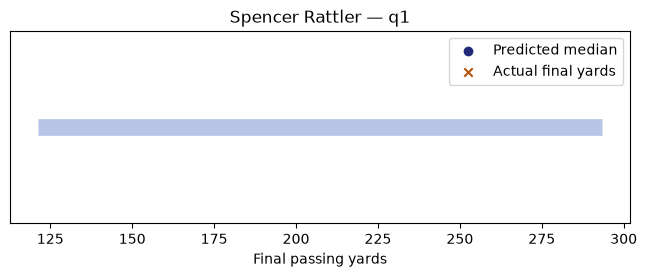

In [14]:
import matplotlib.pyplot as plt
sample = predictions.iloc[0]
plt.figure(figsize=(8, 2.5))
plt.hlines(1, sample.p10, sample.p90, linewidth=12, color='#b8c5e6')
plt.scatter([sample.p50], [1], label='Predicted median', color='#1e2a78')
plt.scatter([sample.official_passing_yards], [1], marker='x', label='Actual final yards', color='#b45309')
plt.yticks([])
plt.xlabel('Final passing yards')
plt.title(f'{sample.actual_qb_name} — {sample.checkpoint}')
plt.legend()
plt.show()

## Optional: download historical Kalshi markets and replay quotes
Set RUN_MARKET_BACKTEST=True above to enable this step. It may make many public API requests and can resume from cache. It uses freshly generated predictions, not saved selections. Markets without a matching player/date or usable timestamped quote are reported as skipped. Q1 chooses highest qualifying edge; halftime is a fallback requiring same-line/side probability confirmation. This simplified market-selection policy differs from the original research configuration.

The report assumes one contract at the recorded ask, fees and 0/5/10¢ additional cost. It cannot establish available quantity or executable fills. A missing market is not a model failure, and a profitable simulation is not realized earnings.

In [15]:
"""Public, cached Kalshi quote-based replay. No live orders or assumed fills.

This deliberately uses public minute-candle closing quotes, not order-book depth.
Freshly computed predictions need not reproduce any previously published result.
"""

from __future__ import annotations

import hashlib
import json
import math
import re
from decimal import Decimal, ROUND_CEILING
from pathlib import Path
from urllib.parse import quote

import numpy as np
import pandas as pd
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

BASE_URL = "https://external-api.kalshi.com/trade-api/v2"


class PublicKalshi:
    """Unauthenticated GET-only client; immutable request-keyed provenance cache."""

    def __init__(self, cache_dir):
        self.cache_dir = Path(cache_dir) / "kalshi"
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.session = requests.Session()
        self.session.mount("https://", HTTPAdapter(max_retries=Retry(
            total=5, backoff_factor=1, status_forcelist=[429, 500, 502, 503, 504],
            allowed_methods=["GET"],
        )))

    def get(self, endpoint, **params):
        url = f"{BASE_URL}/{endpoint}"
        identity = json.dumps([url, params], sort_keys=True)
        path = self.cache_dir / (hashlib.sha256(identity.encode()).hexdigest() + ".json")
        if path.exists():
            record = json.loads(path.read_text())
            if hashlib.sha256(json.dumps(record["payload"], sort_keys=True).encode()).hexdigest() != record["payload_sha256"]:
                raise ValueError(f"Corrupt cached payload: {path}")
            return record["payload"]
        response = self.session.get(url, params=params, timeout=60)
        response.raise_for_status()
        payload = response.json()
        record = dict(url=response.url, retrieved_utc=pd.Timestamp.now(tz="UTC").isoformat(),
                      sha256=hashlib.sha256(response.content).hexdigest(),
                      payload_sha256=hashlib.sha256(json.dumps(payload, sort_keys=True).encode()).hexdigest(), payload=payload)
        temporary = path.with_suffix(".tmp")
        temporary.write_text(json.dumps(record))
        temporary.replace(path)
        return payload

    def markets(self):
        """Download all archived passing-yard markets, following every cursor."""
        result, cursor, seen = [], "", set()
        while True:
            params = {"series_ticker": "KXNFLPASSYDS", "limit": 1000}
            if cursor:
                params["cursor"] = cursor
            page = self.get("historical/markets", **params)
            result.extend(page["markets"])
            cursor = page.get("cursor", "")
            if not cursor:
                break
            if cursor in seen:
                raise RuntimeError("Repeated historical-market cursor; download is incomplete")
            seen.add(cursor)
        return list({m["ticker"]: m for m in result}.values())

    def quote_at(self, ticker, decision_utc, max_age_seconds=300):
        """Last completed minute candle at/before decision; never use future quotes."""
        decision = pd.Timestamp(decision_utc)
        if pd.isna(decision) or decision.tzinfo is None:
            raise ValueError("Decision timestamp must be known and timezone-aware")
        end = int(decision.timestamp())
        payload = self.get(f"historical/markets/{quote(ticker, safe='')}/candlesticks",
                           start_ts=end - max_age_seconds - 60, end_ts=end, period_interval=1)
        candles = [c for c in payload["candlesticks"]
                   if 0 <= decision.timestamp() - c["end_period_ts"] <= max_age_seconds]
        if not candles:
            return {}
        candle = max(candles, key=lambda c: c["end_period_ts"])
        def close(field):
            values = candle.get(field) or {}
            if values.get("close_dollars") is not None:
                return float(values["close_dollars"])
            value = values.get("close")
            if value is None:
                return None
            # Historical fixed-point strings are dollars; legacy integer fields are cents.
            return float(value) if isinstance(value, str) else float(value) / 100
        return dict(quote_utc=pd.Timestamp(candle["end_period_ts"], unit="s", tz="UTC").isoformat(),
                    quote_age_seconds=decision.timestamp() - candle["end_period_ts"],
                    yes_bid=close("yes_bid"), yes_ask=close("yes_ask"))


def normalize_name(name):
    return re.sub(r"[^a-z0-9]", "", str(name).lower())


def market_matches(market, row):
    """Require exact normalized player and original scheduled game date/team pair."""
    name = re.split(r"\s+records\s+\d+\+|:\s*\d+\+", market.get("title", ""),
                    maxsplit=1, flags=re.I)[0]
    if normalize_name(name) != normalize_name(row["actual_qb_name"]):
        return False
    day = pd.Timestamp(row["game_date"]).strftime("%y%b%d").upper()
    suffix = market.get("event_ticker", "").removeprefix("KXNFLPASSYDS-")
    aliases = {"LA": "LAR", "OAK": "LV", "SD": "LAC"}
    team = aliases.get(row["team"], row["team"])
    opponent = aliases.get(row["opponent_team"], row["opponent_team"])
    return suffix in (day + team + opponent, day + opponent + team)


def probability_over(levels, values, threshold):
    levels, values = np.asarray(levels, float), np.asarray(values, float)
    if (levels.ndim != 1 or values.shape != levels.shape or len(levels) < 2
            or not np.isfinite(levels).all() or not np.isfinite(values).all()
            or np.any(np.diff(levels) <= 0) or levels[0] <= 0 or levels[-1] >= 1):
        raise ValueError("Invalid predictive quantiles")
    # Explicit piecewise-linear CDF approximation, monotone-repaired quantiles.
    return float(1 - np.interp(threshold, np.maximum.accumulate(values), levels, left=0, right=1))


def taker_fee(price):
    """Modeled one-contract general taker fee, rounded upward to cents."""
    p = Decimal(str(price))
    return float((Decimal("0.07") * p * (1 - p)).quantize(Decimal("0.01"), rounding=ROUND_CEILING))


def build_candidates(predictions, client, markets=None, max_age_seconds=300, max_spread=.10):
    """Return every matched side and rejected row, including missing data reasons.

    Network errors stop the run (successful requests remain cached), rather than
    silently treating failed downloads as absent liquidity.
    """
    if predictions.empty:
        raise ValueError("No predictions supplied")
    markets = client.markets() if markets is None else markets
    rows = []
    for row in predictions.to_dict("records"):
        base = {k: row[k] for k in ["game_id", "week", "actual_qb_name", "checkpoint", "decision_utc"]}
        if pd.isna(row["decision_utc"]):
            rows.append({**base, "reason": "missing_decision_timestamp"})
            continue
        matches = [m for m in markets if market_matches(m, row) and m.get("floor_strike") is not None]
        if not matches:
            rows.append({**base, "reason": "no_matching_market"})
        for market in matches:
            ticker, threshold = market["ticker"], float(market["floor_strike"])
            if market.get("strike_type") not in ("greater", "structured") or not re.search(r"records \d+\+ passing yards", market.get("title", ""), re.I):
                rows.append({**base, "ticker": ticker, "reason": "unsupported_contract"})
                continue
            p_yes = probability_over(row["quantile_levels"], row["quantile_values"], threshold)
            snapshot = client.quote_at(ticker, row["decision_utc"], max_age_seconds)
            bid, ask = snapshot.get("yes_bid"), snapshot.get("yes_ask")
            reason = "eligible"
            if bid is None or ask is None:
                reason = "missing_quote"
            elif not 0 <= bid <= ask <= 1:
                reason = "invalid_quote"
            elif ask - bid > max_spread + 1e-9:
                reason = "wide_spread"
            settlement = market.get("settlement_value_dollars")
            if settlement is None:
                settlement = {"yes": 1, "no": 0}.get(market.get("result"))
            if settlement is not None and not 0 <= float(settlement) <= 1:
                raise ValueError(f"Invalid settlement value for {ticker}")
            for side, probability, price in [("yes", p_yes, ask), ("no", 1 - p_yes, None if bid is None else 1 - bid)]:
                fee = taker_fee(price) if price is not None and 0 < price < 1 else None
                rows.append({**base, **snapshot, "ticker": ticker, "threshold": threshold,
                             "line": math.floor(threshold) + 1, "side": side,
                             "model_probability": probability, "entry_price": price, "fee": fee,
                             "edge": probability - price - fee if fee is not None else None,
                             "settlement_value": None if settlement is None else (float(settlement) if side == "yes" else 1 - float(settlement)),
                             "reason": "nontradeable_price" if reason == "eligible" and fee is None else reason})
    return pd.DataFrame(rows)


def select_strategy(candidates, min_edge=.10):
    """Freeze Q1 first, halftime fallback; select highest edge deterministically.

    Settlement never influences selection. Only one one-contract position per
    QB/game. Halftime confirmation compares the identical ticker and side.
    """
    audit = candidates.copy()
    audit["selected"] = False
    for _, group in audit.groupby(["game_id", "actual_qb_name"], sort=False):
        previous = {}
        bought = False
        for checkpoint in ["q1", "halftime"]:
            choices = []
            for index, row in group[group.checkpoint == checkpoint].iterrows():
                key = (row.get("ticker"), row.get("side"))
                if checkpoint == "q1" and pd.notna(row.get("model_probability")):
                    previous[key] = row["model_probability"]
                if row["reason"] != "eligible":
                    continue
                reason = None
                if bought:
                    reason = "earlier_entry"
                elif row["edge"] < min_edge - 1e-12:
                    reason = "below_edge"
                elif checkpoint == "halftime" and key not in previous:
                    reason = "missing_q1_confirmation"
                elif checkpoint == "halftime" and row["model_probability"] < previous[key]:
                    reason = "probability_not_confirmed"
                if reason:
                    audit.at[index, "reason"] = reason
                else:
                    choices.append(index)
            if choices:
                winner = sorted(choices, key=lambda i: (-audit.at[i, "edge"], audit.at[i, "ticker"], audit.at[i, "side"]))[0]
                for index in choices:
                    audit.at[index, "reason"] = "selected" if index == winner else "lower_priority"
                audit.at[winner, "selected"] = True
                bought = True
    selected = audit[audit.selected].copy()
    selected["stake_contracts"] = 1
    if len(selected):
        selected["capital"] = selected.entry_price + selected.fee
        selected["profit"] = selected.settlement_value - selected.capital
        for cents in (5, 10):
            selected[f"capital_plus_{cents}c"] = selected.capital + cents / 100
            selected[f"profit_plus_{cents}c"] = selected.profit - cents / 100
    return audit, selected


def summarize(selected, allowances=(0, .05, .10)):
    """One-contract quote-based P&L, including each checkpoint and combined."""
    results = []
    for checkpoint in ["q1", "halftime", "combined"]:
        rows = selected if checkpoint == "combined" else selected[selected.checkpoint == checkpoint]
        if len(rows) and rows.settlement_value.isna().any():
            raise ValueError("Selected markets are unsettled: cannot report complete P&L")
        for allowance in allowances:
            capital = float((rows.entry_price + rows.fee + allowance).sum()) if len(rows) else 0
            payout = float(rows.settlement_value.sum()) if len(rows) else 0
            results.append(dict(checkpoint=checkpoint, allowance=allowance, entries=len(rows),
                                capital=capital, profit=payout-capital,
                                return_on_deployed=(payout-capital)/capital if capital else None))
    return pd.DataFrame(results)


def run_backtest(predictions, cache_dir, output_dir, **selection_options):
    """Download public data, write candidate reasons/entries/results, and return all."""
    candidates = build_candidates(predictions, PublicKalshi(cache_dir))
    audit, selected = select_strategy(candidates, **selection_options)
    report = summarize(selected)
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    audit.to_csv(output_dir / "candidate_audit.csv", index=False)
    selected.to_csv(output_dir / "selected_entries.csv", index=False)
    report.to_csv(output_dir / "quote_based_results.csv", index=False)
    return audit, selected, report


In [16]:
if RUN_MARKET_BACKTEST:
    audit, entries, betting_metrics = run_backtest(predictions, CACHE_DIR, OUTPUT_DIR, min_edge=.10)
    display(betting_metrics)
    display(audit.reason.value_counts())
else:
    print('Kalshi skipped. Fresh prediction and forecast evaluation are complete.')

Kalshi skipped. Fresh prediction and forecast evaluation are complete.


In [17]:
import json, hashlib
manifest = {'packages': {p: metadata.version(p) for p in required},
    'start_season':START_SEASON,'test_season':TEST_SEASON,'min_week':MIN_WEEK,'max_week':MAX_WEEK,
    'context_limit':CONTEXT_LIMIT,'weekly_update':WEEKLY_UPDATE,'model':'nori-6m','device':DEVICE,
    'sources':[json.loads(p.read_text()) for p in CACHE_DIR.glob('*.source.json')],
    'prediction_sha256':hashlib.sha256((OUTPUT_DIR/'predictions.parquet').read_bytes()).hexdigest()}
(OUTPUT_DIR/'run_manifest.json').write_text(json.dumps(manifest,indent=2))
print('Artifacts saved in', OUTPUT_DIR.resolve())

Artifacts saved in /tmp/nfl-rendered-notebook-7eiut84r/nfl_passing_yards_outputs
